In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train_meta.csv
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/cliniscan_classification_model.pth
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train.csv
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/cliniscan_detection_model (1).pt
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/b3f67ac077531f44dd06275af31edbd9.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/e94fde220360e4b769921e16059cc6af.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/d2993271d0a49d1d821db1174861629a.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/99732e844196448b90e50973d6ba5224.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/3c6f70f56258cad13d74e7f17da1c7c5.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/5d6a25163584e7b05a528d3f94fda500.png
/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/435c653f95dd47326063ff145a0fa82e.png
/kaggle/input/datas

In [2]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

# DETECTION (YOLO)

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.9 MB/s eta 0:00:00


In [4]:
#DETECTION (YOLO)
from ultralytics import YOLO

det_model = YOLO("/kaggle/input/datasets/dasandco/cliniscanpipelinedata/cliniscan_detection_model (1).pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
train_csv = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train.csv"
meta_csv = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train_meta.csv"

df = pd.read_csv(train_csv)
meta = pd.read_csv(meta_csv)

print("Train rows:", len(df))
print("Meta rows:", len(meta))

Train rows: 67914
Meta rows: 15000


In [6]:
df = df[df["class_id"] != 14]

print("After removing No finding:", len(df))

After removing No finding: 36096


In [7]:
df = df.dropna(subset=["x_min","y_min","x_max","y_max"])

print("Valid annotations:", len(df))

Valid annotations: 36096


In [8]:
size_dict = {}

for _, row in meta.iterrows():
    size_dict[row["image_id"]] = (row["dim0"], row["dim1"])

In [9]:
base = "/kaggle/working/dataset"

img_dir = f"{base}/images/train"
lbl_dir = f"{base}/labels/train"

os.makedirs(img_dir, exist_ok=True)
os.makedirs(lbl_dir, exist_ok=True)

In [10]:
from tqdm import tqdm
for img_id, group in tqdm(df.groupby("image_id")):

    h, w = size_dict[img_id]

    label_path = os.path.join(lbl_dir, img_id + ".txt")

    with open(label_path, "w") as f:

        for _, row in group.iterrows():

            x_min = row["x_min"]
            y_min = row["y_min"]
            x_max = row["x_max"]
            y_max = row["y_max"]

            xc = ((x_min + x_max) / 2) / w
            yc = ((y_min + y_max) / 2) / h

            bw = (x_max - x_min) / w
            bh = (y_max - y_min) / h

            class_id = int(row["class_id"])

            f.write(f"{class_id} {xc} {yc} {bw} {bh}\n")

100%|██████████| 4394/4394 [00:02<00:00, 1579.76it/s]


In [11]:
src_img_dir = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata/train"

for img in tqdm(os.listdir(src_img_dir)):
    
    src = os.path.join(src_img_dir, img)
    dst = os.path.join(img_dir, img)

    if not os.path.exists(dst):
        os.system(f"cp {src} {dst}")

100%|██████████| 15001/15001 [02:38<00:00, 94.61it/s] 


In [12]:
images = set([os.path.splitext(f)[0] for f in os.listdir(img_dir)])
labels = set([os.path.splitext(f)[0] for f in os.listdir(lbl_dir)])

missing = images - labels

for img in missing:
    open(os.path.join(lbl_dir, img + ".txt"), "w").close()

print("Empty labels created:", len(missing))

Empty labels created: 10607


In [13]:
print("Images:", len(os.listdir(img_dir)))
print("Labels:", len(os.listdir(lbl_dir)))

Images: 15001
Labels: 15001


In [14]:
data_yaml = """
train: /kaggle/working/dataset/images/train
val: /kaggle/working/dataset/images/train

nc: 14

names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcification
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung Opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumothorax
  13: Pulmonary fibrosis
"""

with open("/kaggle/working/data.yaml","w") as f:
    f.write(data_yaml)

In [15]:
det_model.train(
    data='/kaggle/working/data.yaml',
    epochs=30,
    imgsz=1024,
    batch=8,

    lr0=0.0005,
    momentum=0.937,
    weight_decay=0.0005,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,

    patience=5,
    device=0
)

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/datasets/dasandco/cliniscanpipelinedata/cliniscan_detection_model (1).pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=N

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b4df3d9ac60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [16]:
metrics = det_model.val(data='/kaggle/working/data.yaml')
print(metrics)

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 101 layers, 9,418,218 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2794.0±1160.3 MB/s, size: 409.9 KB)
val: Scanning /kaggle/working/dataset/labels/train.cache... 15000 images, 10606 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15000/15000 4.5Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 938/938 3.9it/s 4:03
                   all      15000      36096      0.493      0.425      0.436      0.232
    Aortic enlargement       3067       7162      0.658      0.621      0.682      0.436
           Atelectasis        186        279      0.376      0.348      0.329      0.149
         Calcification        452        960      0.375       0.44      0.366       0.18
          Cardiomegaly       2300       5427      0.744      0.562      0.671      0.451
         Conso


image 1/1 /kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/074e3cceb0c1677a1ad0dbff31167d7d.png: 1024x1024 1 Pleural effusion, 15.4ms
Speed: 3.2ms preprocess, 15.4ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 1024)


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

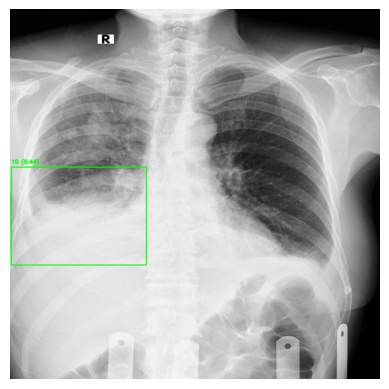

In [17]:
img_path = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata/test/074e3cceb0c1677a1ad0dbff31167d7d.png"

results = det_model(img_path)

img = cv2.imread(img_path)

for r in results:
    boxes = r.boxes.xyxy.cpu().numpy()
    cls = r.boxes.cls.cpu().numpy()
    conf = r.boxes.conf.cpu().numpy()

    for box, c, cf in zip(boxes, cls, conf):
        x1, y1, x2, y2 = map(int, box)
        label = f"{int(c)} ({cf:.2f})"

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img, label, (x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

# CLASSIFICATION

In [18]:
import pandas as pd

BASE_PATH = "/kaggle/input/datasets/dasandco/cliniscanpipelinedata"

df = pd.read_csv(BASE_PATH + "/train.csv")

# create image path
df['image_path'] = BASE_PATH + "/train/" + df['image_id'] + ".png"

# fix labels (IMPORTANT)
df['label'] = df['class_id']

# keep valid labels only
df = df[(df['label'] >= 0) & (df['label'] < 14)]

# remove duplicates (same image multiple boxes)
df = df.drop_duplicates(subset=['image_id'])

print("Data size:", len(df))
print("Label range:", df['label'].min(), df['label'].max())

Data size: 4394
Label range: 0 13


In [19]:
#Data Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

In [20]:
import cv2
import torch
from torch.utils.data import Dataset

class XRayDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = row['image_path']
        image = cv2.imread(img_path)

        if image is None:
            raise ValueError(f"Image not found: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)['image']

        label = torch.tensor(int(row['label']), dtype=torch.long)

        return image, label

In [21]:
from torch.utils.data import DataLoader

train_dataset = XRayDataset(df, transform=train_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

# test
images, labels = next(iter(train_loader))
print(images.shape, labels.min(), labels.max())

torch.Size([16, 3, 224, 224]) tensor(0) tensor(13)


In [22]:
from torchvision import models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights="IMAGENET1K_V1")

# freeze backbone
for param in model.parameters():
    param.requires_grad = False

# replace final layer
model.fc = nn.Linear(model.fc.in_features, 14)

# unfreeze last block
for param in model.layer4.parameters():
    param.requires_grad = True

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


In [23]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [24]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 573.3088
Epoch 2, Loss: 533.6308
Epoch 3, Loss: 509.0014
Epoch 4, Loss: 482.0233
Epoch 5, Loss: 450.4087
Epoch 6, Loss: 394.6429
Epoch 7, Loss: 357.3469
Epoch 8, Loss: 344.2397
Epoch 9, Loss: 323.4296
Epoch 10, Loss: 311.5774


In [25]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='macro')

print("Accuracy:", acc)
print("F1 Score:", f1)

Accuracy: 0.6816112881201638
F1 Score: 0.5886329978132604


# Grad-CAM

In [26]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 61.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=f5d7ee77f0c67180bd41033115132b1bcf00f4d7e4474f274a2bd1ef7f65ac27
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

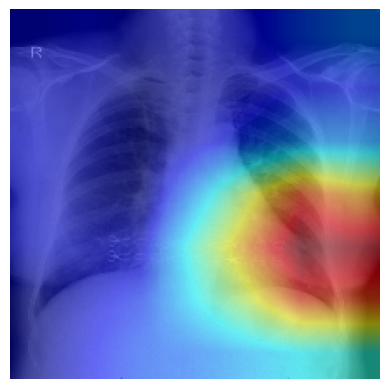

In [27]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt

target_layer = model.layer4[-1]

cam = GradCAM(model=model, target_layers=[target_layer])

img, _ = train_dataset[0]
input_tensor = img.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)

img_np = img.permute(1,2,0).numpy()
img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

visualization = show_cam_on_image(img_np, grayscale_cam[0], use_rgb=True)

plt.imshow(visualization)
plt.axis('off')

In [28]:
torch.save(model.state_dict(), "/kaggle/working/final_classification_model.pth")